In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pathlib
import tensorflow as tf
import pandas as pd
from PIL import Image
import random
from skimage.measure import label, regionprops
from skimage.filters import threshold_otsu
import shutil
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import load_img
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, Dense, BatchNormalization, Activation, Dropout, MaxPooling2D, Flatten
from keras.optimizers import Adam, RMSprop, SGD
from keras import regularizers
from keras.callbacks import ModelCheckpoint, CSVLogger, TensorBoard, EarlyStopping, ReduceLROnPlateau
import datetime
from keras.utils import plot_model
from tensorflow.keras.utils import image_dataset_from_directory
from skimage.measure import shannon_entropy
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from glob import glob
from skimage.io import imread
from skimage.color import rgb2gray
from sklearn.feature_extraction import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Input, Conv2D, DepthwiseConv2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing import image
import pathlib
import cv2
import numpy as np
from scipy import ndimage
import pathlib
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2, InceptionV3
from tensorflow.keras.optimizers import Adam




In [ ]:

Train = '/content/drive/MyDrive/skin_cancer/data/train/'
Test= '/content/drive/MyDrive/skin_cancer/data/test/'

benignPath = os.path.join(Train,'bening')
malignantPath = os.path.join(Train,'malignant')


In [ ]:
path = '/content/drive/MyDrive/skin_cancer/data/test/'
data_dir = pathlib.Path(path)

# Define the subdirectories for each class
benignPath = os.path.join(data_dir, 'benign')
malignantPath = os.path.join(data_dir, 'malignant')

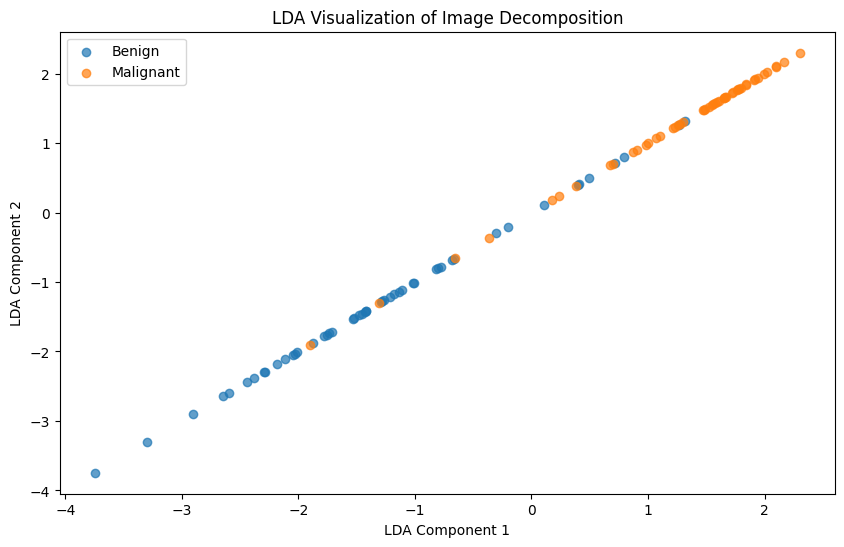

In [ ]:




# Function to load and preprocess an image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array.reshape((1, *img_array.shape))
    return img_array

# Load images and extract features
def load_images_and_extract_features(directory, label, num_samples=None):
    images = []
    labels = []

    for img_name in os.listdir(directory)[:num_samples]:
        img_path = os.path.join(directory, img_name)
        img_array = load_and_preprocess_image(img_path)
        images.append(img_array.flatten())
        labels.append(label)

    return images, labels

# Load images and labels for benign and malignant classes
num_samples_per_class = 50  # You can adjust the number of samples
benign_images, benign_labels = load_images_and_extract_features(benignPath, label=0, num_samples=num_samples_per_class)
malignant_images, malignant_labels = load_images_and_extract_features(malignantPath, label=1, num_samples=num_samples_per_class)

# Concatenate images and labels
all_images = np.concatenate([benign_images, malignant_images], axis=0)
all_labels = np.concatenate([benign_labels, malignant_labels], axis=0)

# Standardize the features
scaler = StandardScaler()
all_images_standardized = scaler.fit_transform(all_images)

# Apply Linear Discriminant Analysis (LDA)
# Set n_components to the minimum of n_features and n_classes-1
n_components = min(all_images_standardized.shape[1], len(np.unique(all_labels)) - 1)
lda = LinearDiscriminantAnalysis(n_components=n_components)
lda_result = lda.fit_transform(all_images_standardized, all_labels)

# Visualize the LDA result
plt.figure(figsize=(10, 6))
plt.scatter(lda_result[all_labels == 0, 0], lda_result[all_labels == 0, 0], label='Benign', alpha=0.7)
plt.scatter(lda_result[all_labels == 1, 0], lda_result[all_labels == 1, 0], label='Malignant', alpha=0.7)
plt.title('LDA Visualization of Image Decomposition')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.legend()
plt.show()


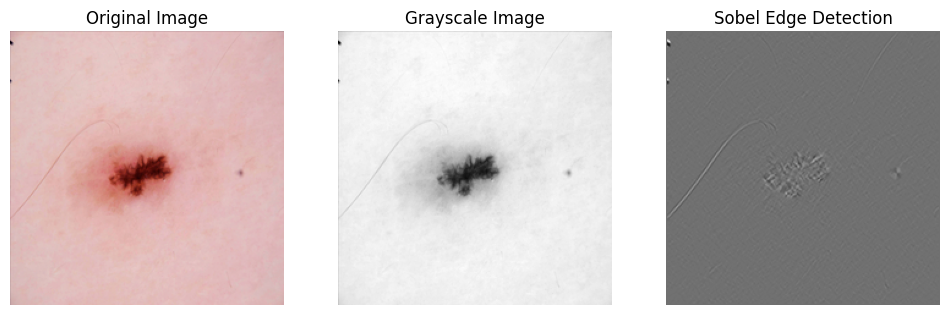

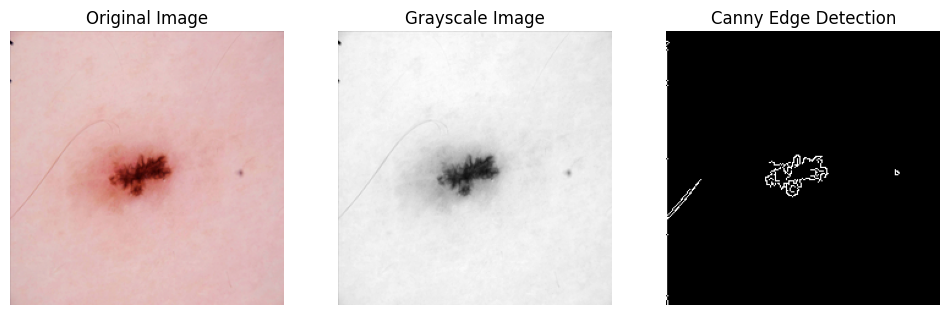

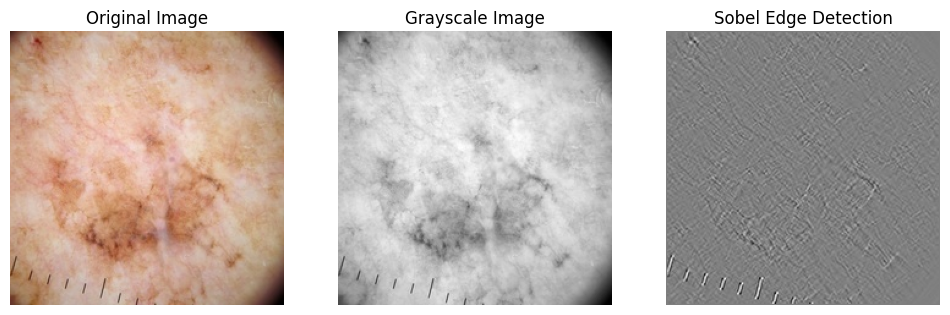

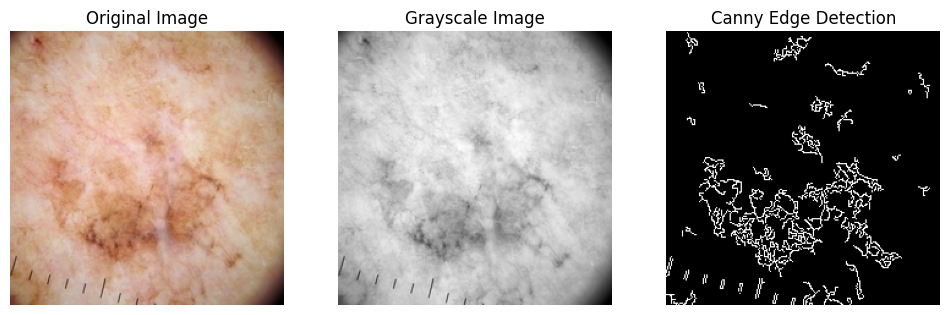

In [ ]:


# Function to load and preprocess an image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array.reshape((1, *img_array.shape))
    return img_array

# Function to apply edge detection and visualize the results
def apply_edge_detection(image_path, method='sobel'):
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)
    img = img.squeeze().astype('uint8')

    # Convert the image to grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Apply edge detection
    if method == 'sobel':
        edges = cv2.Sobel(gray_img, cv2.CV_64F, 1, 1, ksize=3)
    elif method == 'canny':
        edges = cv2.Canny(gray_img, 50, 150)

    # Visualize the results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gray_img, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(edges, cmap='gray')
    plt.title(f'{method.capitalize()} Edge Detection')
    plt.axis('off')

    plt.show()

# Choose an image path from the benign class
sample_benign_image_path = os.path.join(benignPath, os.listdir(benignPath)[0])

# Apply Sobel edge detection on the chosen image
apply_edge_detection(sample_benign_image_path, method='sobel')

# Apply Canny edge detection on the chosen image
apply_edge_detection(sample_benign_image_path, method='canny')

# Choose an image path from the benign class
sample_malignantPath = os.path.join(malignantPath, os.listdir(benignPath)[0])

# Apply Sobel edge detection on the chosen image
apply_edge_detection(sample_malignantPath, method='sobel')

# Apply Canny edge detection on the chosen image
apply_edge_detection(sample_malignantPath, method='canny')


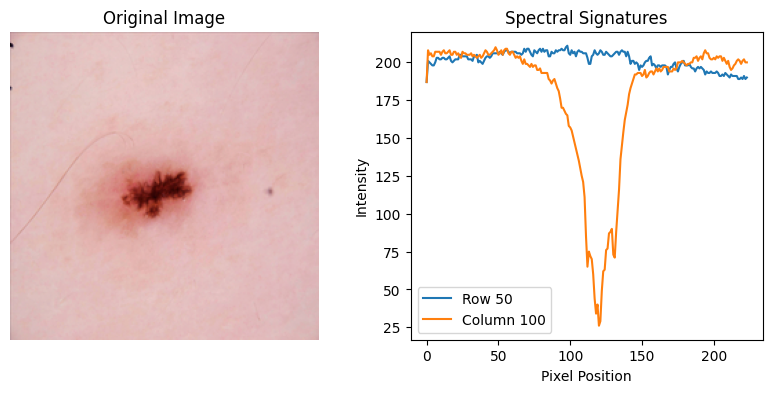

In [ ]:


# Function to load and preprocess an image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array.reshape((1, *img_array.shape))
    return img_array

# Choose an image path from the benign class
sample_benign_image_path = os.path.join(benignPath, os.listdir(benignPath)[0])

# Load and preprocess the image
img = load_and_preprocess_image(sample_benign_image_path)
img = img.squeeze().astype('uint8')

# Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Visualize the original image and its spectral signatures
plt.figure(figsize=(10, 4))

# Plot the original image
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

# Plot the spectral signatures
plt.subplot(1, 2, 2)
plt.plot(gray_img[50, :], label='Row 50')
plt.plot(gray_img[:, 100], label='Column 100')
plt.title('Spectral Signatures')
plt.xlabel('Pixel Position')
plt.ylabel('Intensity')
plt.legend()

plt.show()


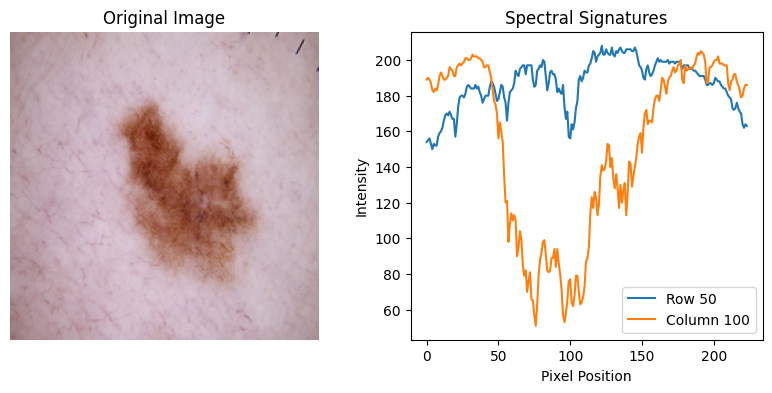

In [ ]:


# Function to load and preprocess an image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array.reshape((1, *img_array.shape))
    return img_array

# Choose an image path from the benign class
sample_malignantPath = os.path.join(malignantPath, os.listdir(malignantPath)[0])

# Load and preprocess the image
img = load_and_preprocess_image(sample_malignantPath)
img = img.squeeze().astype('uint8')

# Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Visualize the original image and its spectral signatures
plt.figure(figsize=(10, 4))

# Plot the original image
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

# Plot the spectral signatures
plt.subplot(1, 2, 2)
plt.plot(gray_img[50, :], label='Row 50')
plt.plot(gray_img[:, 100], label='Column 100')
plt.title('Spectral Signatures')
plt.xlabel('Pixel Position')
plt.ylabel('Intensity')
plt.legend()

plt.show()


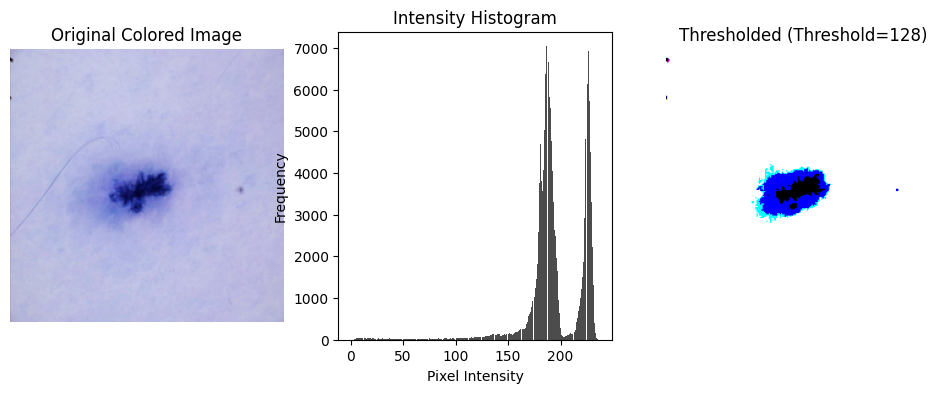

In [ ]:



# Function to load and preprocess an image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array.reshape((1, *img_array.shape))
    return img_array

# Function to perform colored image thresholding and visualize the results
def apply_colored_image_thresholding(image_path, threshold_value=128):
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)
    img = img.squeeze().astype('uint8')

    # Apply image thresholding to each color channel
    thresholded_channels = [cv2.threshold(img[:, :, i], threshold_value, 255, cv2.THRESH_BINARY)[1] for i in range(3)]
    thresholded_img = cv2.merge(thresholded_channels)

    # Visualize the results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Colored Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.hist(img.ravel(), bins=256, color='black', alpha=0.7)
    plt.title('Intensity Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(thresholded_img, cv2.COLOR_BGR2RGB))
    plt.title(f'Thresholded (Threshold={threshold_value})')
    plt.axis('off')

    plt.show()

# Choose an image path from the benign class
sample_benign_image_path = os.path.join(benignPath, os.listdir(benignPath)[0])

# Apply colored image thresholding on the chosen image
apply_colored_image_thresholding(sample_benign_image_path, threshold_value=128)


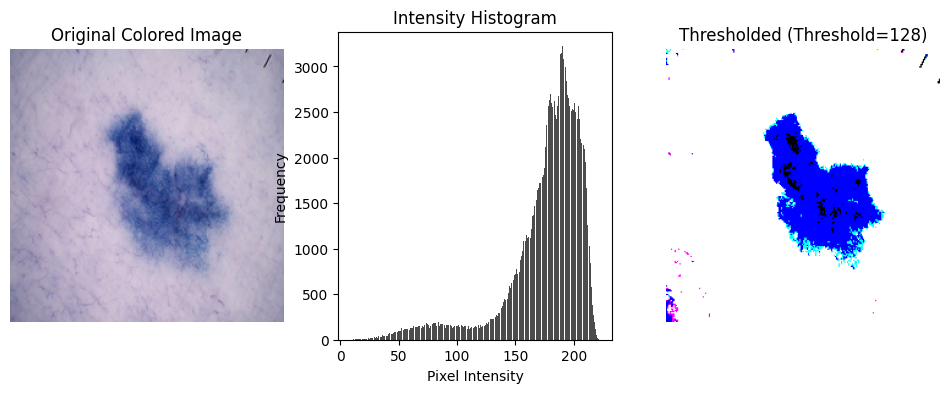

In [ ]:


# Function to load and preprocess an image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array.reshape((1, *img_array.shape))
    return img_array

# Function to perform colored image thresholding and visualize the results
def apply_colored_image_thresholding(image_path, threshold_value=128):
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)
    img = img.squeeze().astype('uint8')

    # Apply image thresholding to each color channel
    thresholded_channels = [cv2.threshold(img[:, :, i], threshold_value, 255, cv2.THRESH_BINARY)[1] for i in range(3)]
    thresholded_img = cv2.merge(thresholded_channels)

    # Visualize the results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Colored Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.hist(img.ravel(), bins=256, color='black', alpha=0.7)
    plt.title('Intensity Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(thresholded_img, cv2.COLOR_BGR2RGB))
    plt.title(f'Thresholded (Threshold={threshold_value})')
    plt.axis('off')

    plt.show()

# Choose an image path from the benign class
sample_malignantPath = os.path.join(malignantPath, os.listdir(malignantPath)[0])

# Apply colored image thresholding on the chosen image
apply_colored_image_thresholding(sample_malignantPath, threshold_value=128)


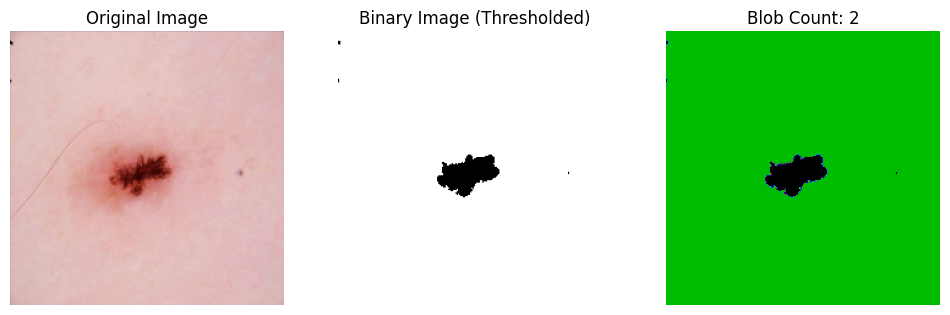

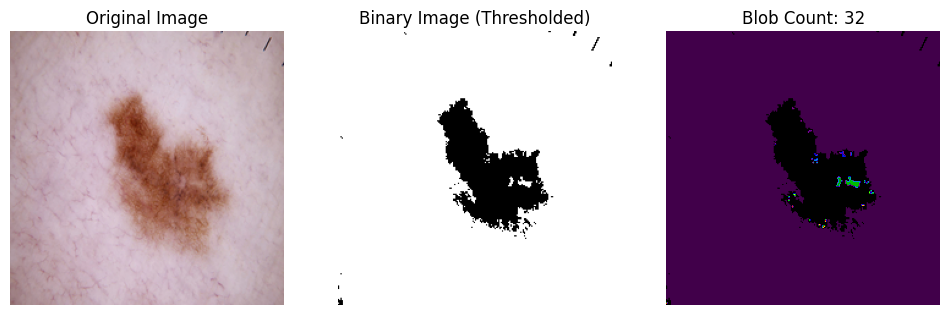

In [ ]:


# Function to load and preprocess an image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    return img

# Function to perform blob counting and visualization
def count_and_visualize_blobs(image_path, threshold_value=128):
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)

    # Convert the image to grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Apply image thresholding
    _, binary_img = cv2.threshold(gray_img, threshold_value, 255, cv2.THRESH_BINARY)

    # Perform blob counting
    labeled_img, num_labels = ndimage.label(binary_img)

    # Visualize the original image, binary image, and labeled blobs
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(binary_img, cmap='gray')
    plt.title('Binary Image (Thresholded)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(labeled_img, cmap='nipy_spectral')
    plt.title(f'Blob Count: {num_labels}')
    plt.axis('off')

    plt.show()

# Choose one sample image from the 'benign' directory
benign_images = os.listdir(benignPath)
sample_benign_image = os.path.join(benignPath, benign_images[0])
count_and_visualize_blobs(sample_benign_image, threshold_value=128)

# Choose one sample image from the 'malignant' directory
malignant_images = os.listdir(malignantPath)
sample_malignant_image = os.path.join(malignantPath, malignant_images[0])
count_and_visualize_blobs(sample_malignant_image, threshold_value=128)


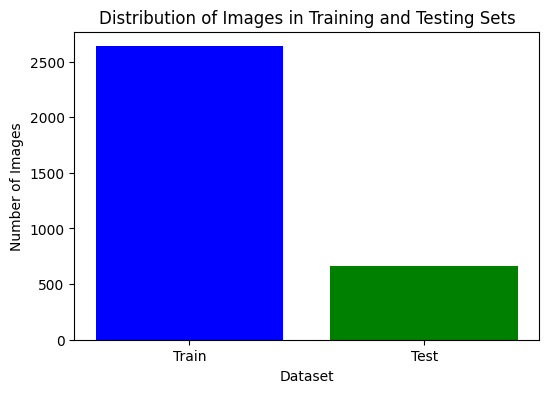

In [ ]:

# Count the number of images in the train and test directories
num_train_images = sum(len(files) for _, _, files in os.walk(Train))
num_test_images = sum(len(files) for _, _, files in os.walk(Test))
# Define class labels
sets = ['Train', 'Test']

# Count of images in each set
set_counts = [num_train_images, num_test_images]

# Create a bar plot
plt.figure(figsize=(6, 4))
plt.bar(sets, set_counts, color=['blue', 'green'])
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Distribution of Images in Training and Testing Sets')
plt.show()


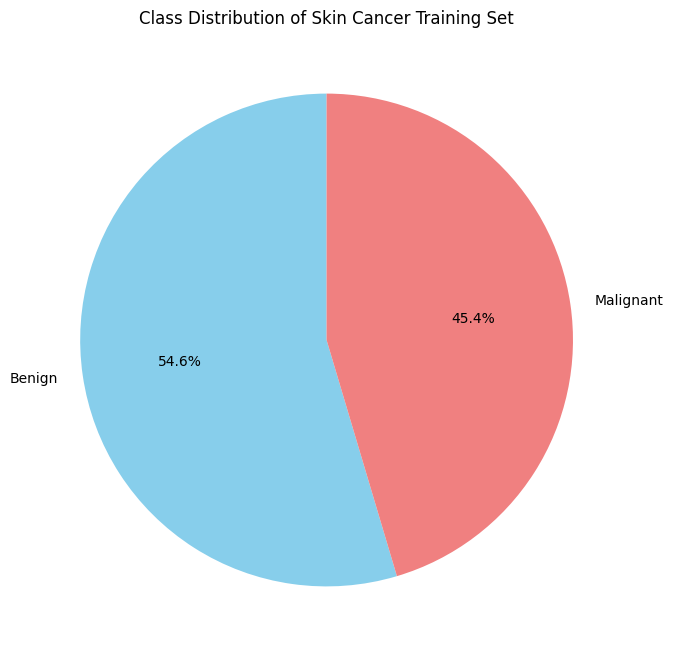

In [ ]:

# Define the path to your dataset
path = '/content/drive/MyDrive/skin_cancer/data/train/'
data_dir = pathlib.Path(path)

# Define the subdirectories for each class
benignPath = os.path.join(data_dir, 'benign')
malignantPath = os.path.join(data_dir, 'malignant')


# Count the number of images in each class
num_benign_images = len(os.listdir(benignPath))
num_malignant_images = len(os.listdir(malignantPath))


# Define class labels
classes = ['Benign', 'Malignant']

# Count of images in each class
class_counts = [num_benign_images, num_malignant_images]

# Create a bar plot
# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=classes, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=90)
plt.title('Class Distribution of Skin Cancer Training Set')
plt.show()



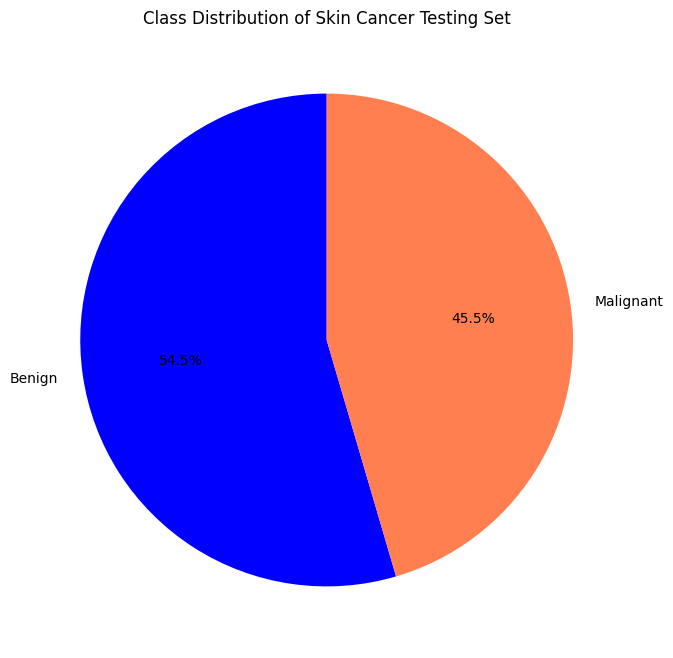

In [ ]:

# Define the path to your dataset
path = '/content/drive/MyDrive/skin_cancer/data/test/'
data_dir = pathlib.Path(path)

# Define the subdirectories for each class
benignPath = os.path.join(data_dir, 'benign')
malignantPath = os.path.join(data_dir, 'malignant')


# Count the number of images in each class
num_benign_images = len(os.listdir(benignPath))
num_malignant_images = len(os.listdir(malignantPath))


# Define class labels
classes = ['Benign', 'Malignant']

# Count of images in each class
class_counts = [num_benign_images, num_malignant_images]

# Create a bar plot
# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=classes, autopct='%1.1f%%', colors=['blue', 'coral'], startangle=90)
plt.title('Class Distribution of Skin Cancer Testing Set')
plt.show()


In [ ]:

# Define data augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.Rescaling(1./255),
    layers.experimental.preprocessing.RandomFlip("horizontal"),
    layers.experimental.preprocessing.RandomRotation(0.2),
    layers.experimental.preprocessing.RandomZoom(0.2),
])

# Load and preprocess the data
train_data = image_dataset_from_directory(
    Train,
    seed=123,
    interpolation='bilinear',
    color_mode='rgb',
    crop_to_aspect_ratio=True,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32,
)

val_data = image_dataset_from_directory(
    Test,
    seed=123,
    interpolation='bilinear',
    color_mode='rgb',
    crop_to_aspect_ratio=True,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32,
)

# Preprocess and augment the data
train_data = train_data.map(lambda x, y: (data_augmentation(x), y))
val_data = val_data.map(lambda x, y: (data_augmentation(x), y))

Found 2637 files belonging to 2 classes.
Found 660 files belonging to 2 classes.


In [ ]:

# Define data augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.Rescaling(1./255),
    layers.experimental.preprocessing.RandomFlip("horizontal"),
    layers.experimental.preprocessing.RandomRotation(0.2),
    layers.experimental.preprocessing.RandomZoom(0.2),
])

# Load and preprocess the data
train_data = image_dataset_from_directory(
    Train,
    seed=123,
    interpolation='bilinear',
    color_mode='rgb',
    crop_to_aspect_ratio=True,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32,
)

val_data = image_dataset_from_directory(
    Test,
    seed=123,
    interpolation='bilinear',
    color_mode='rgb',
    crop_to_aspect_ratio=True,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32,
)

# Preprocess and augment the data
train_data = train_data.map(lambda x, y: (data_augmentation(x), y))
val_data = val_data.map(lambda x, y: (data_augmentation(x), y))

# Define the base models
base_model_resnet = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model_mobilenet = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model_inception = InceptionV3(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Freeze the layers of the base models
base_model_resnet.trainable = False
base_model_mobilenet.trainable = False
base_model_inception.trainable = False

# Define the late fusion model
inputs = tf.keras.Input(shape=(224, 224, 3))
x1 = base_model_resnet(inputs, training=False)
x1 = layers.GlobalAveragePooling2D()(x1)  # Add global average pooling layer
x1 = layers.Dense(512, activation='relu')(x1)
x1 = layers.Dropout(0.5)(x1)

x2 = base_model_mobilenet(inputs, training=False)
x2 = layers.GlobalAveragePooling2D()(x2)  # Add global average pooling layer
x2 = layers.Dense(512, activation='relu')(x2)
x2 = layers.Dropout(0.5)(x2)

x3 = base_model_inception(inputs, training=False)
x3 = layers.GlobalAveragePooling2D()(x3)  # Add global average pooling layer
x3 = layers.Dense(512, activation='relu')(x3)
x3 = layers.Dropout(0.5)(x3)

# Concatenate the outputs of the base models
x = layers.Concatenate()([x1, x2, x3])

# Depthwise convolutional layer
x = layers.Reshape((1, 1, -1))(x)  # Reshape to (1, 1, channels)
x = layers.DepthwiseConv2D((3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(512, (1, 1), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)

# Additional dense layers
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Additional depthwise convolutional layer
x = layers.Reshape((1, 1, -1))(x)
x = layers.DepthwiseConv2D((3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(256, (1, 1), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)

# Additional dense layer
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Fully connected layer for classification
outputs = layers.Dense(1, activation='sigmoid')(x)

# Create the model
late_fusion_model = models.Model(inputs, outputs)

# Compile the model
late_fusion_model.compile(optimizer=Adam(learning_rate=0.001),
                          loss='binary_crossentropy',
                          metrics=['accuracy'])

# Display the model summary
late_fusion_model.summary()

# Train the model
history = late_fusion_model.fit(train_data, validation_data=val_data, epochs=50)


Found 2637 files belonging to 2 classes.
Found 660 files belonging to 2 classes.
87910968/87910968 [==============================] - 0s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 resnet50 (Functional)       (None, 7, 7, 2048)           2358771   ['input_4[0][0]']             
                                                          2                                       
                                                                                                  
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)           2257984   ['input_4[0][0]']             
 tional)                                       

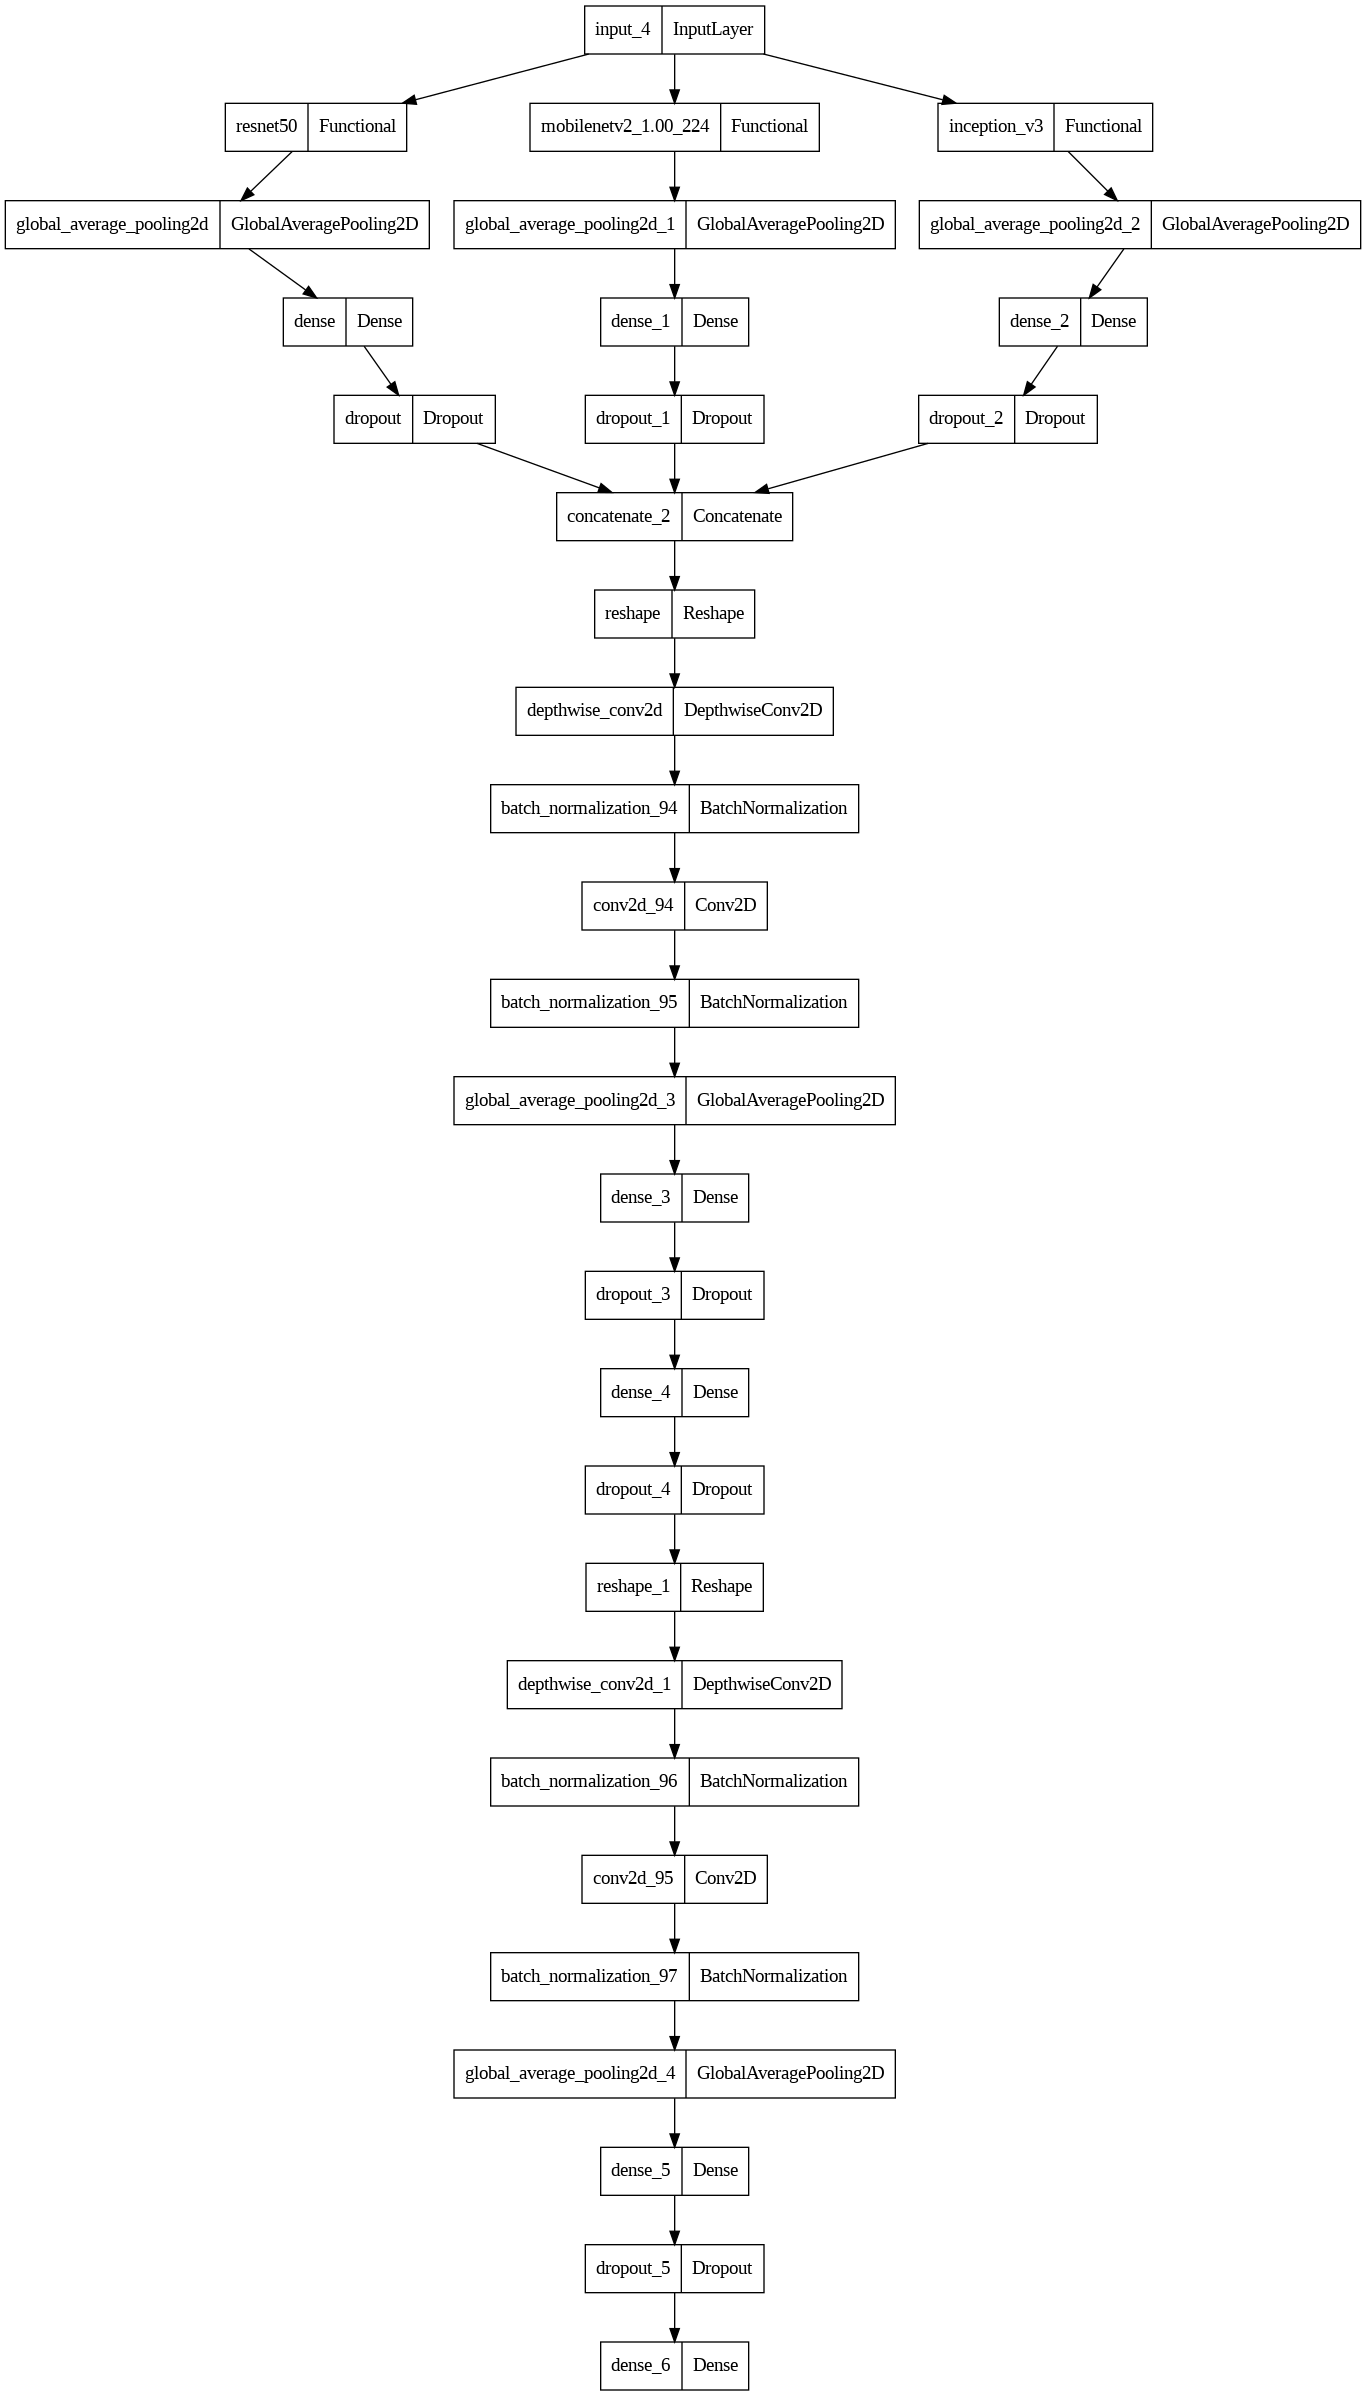

In [ ]:

plot_model(late_fusion_model)

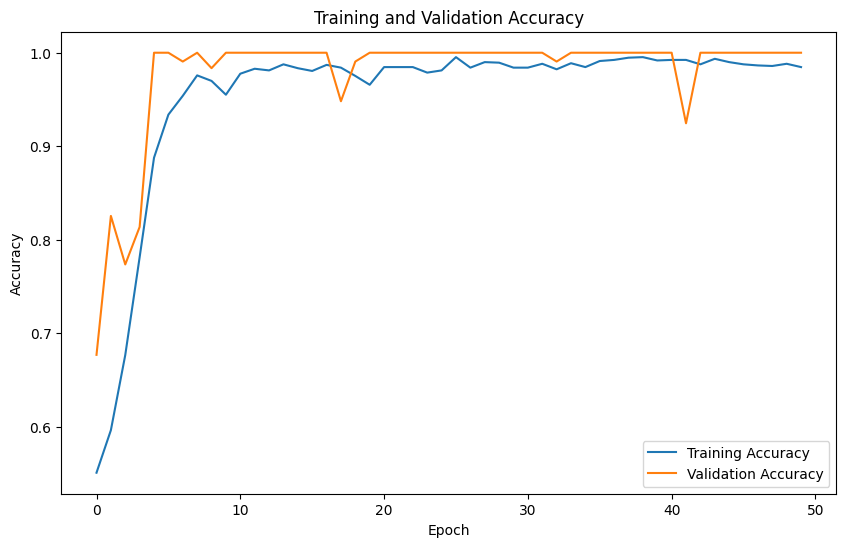

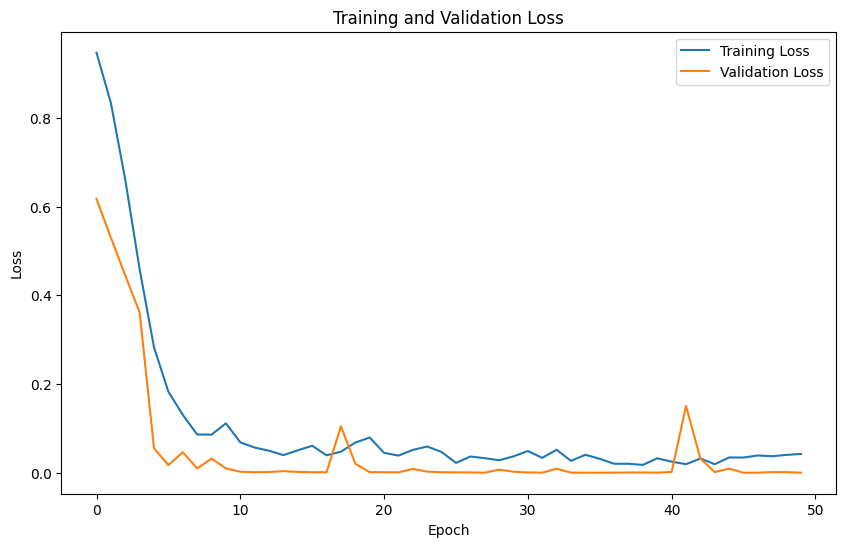

In [ ]:

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
test_loss, test_accuracy = late_fusion_model.evaluate(val_data)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.997


In [ ]:
ypred=late_fusion_model.predict(val_data)

21/21 [==============================] - 16s 579ms/step


In [ ]:
true_labels = []
predicted_labels = []

for images, labels in val_data:
    true_labels.extend(labels.numpy())
    predicted_probs = late_fusion_model.predict(images)
    predicted_labels.extend((predicted_probs > 0.5).astype(int).flatten())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

1/1 [==============================] - 6s 6s/step


In [ ]:
macro_averaged_precision = metrics.precision_score(true_labels, predicted_labels, average = 'macro')
print(f"Macro-Averaged Precision score using sklearn library : {macro_averaged_precision}")

Macro-Averaged Precision score using sklearn library : 0.9912


In [ ]:
macro_averaged_recall = metrics.recall_score(true_labels, predicted_labels, average = 'macro')
print(f"Macro-averaged recall score using sklearn : {macro_averaged_recall}")

Macro-averaged recall score using sklearn : 0.9934


In [ ]:
macro_averaged_f1 = metrics.f1_score(true_labels, predicted_labels, average = 'macro')
print(f"Macro-Averaged F1 score using sklearn library : {macro_averaged_f1}")

Macro-Averaged F1 score using sklearn library : 0.9975


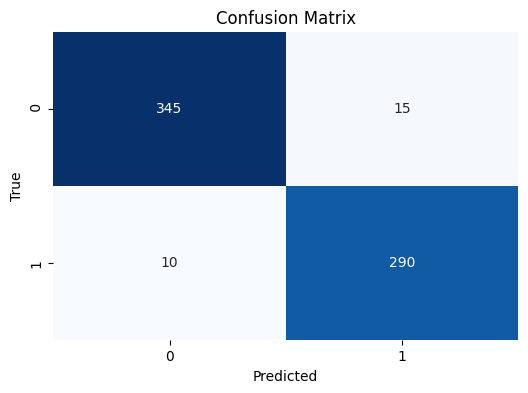

In [ ]:

confusion = confusion_matrix(true_labels, predicted_labels)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

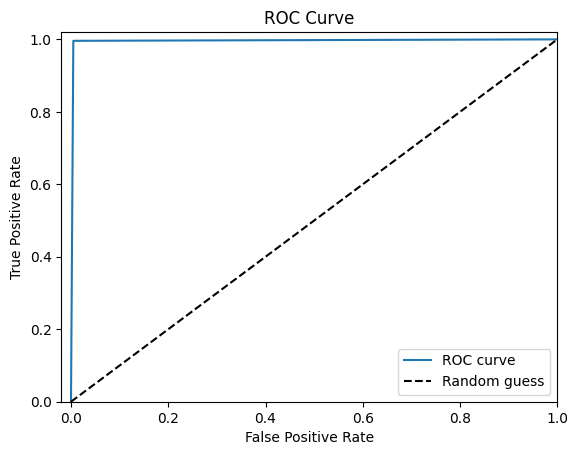

In [ ]:


fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels)

plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.xlim([-0.02, 1])
plt.ylim([0, 1.02])
plt.legend(loc="lower right")


In [ ]:

Train = '/content/drive/MyDrive/skin_cancer2/melanoma_cancer_dataset/train/'
Test= '/content/drive/MyDrive/skin_cancer2/melanoma_cancer_dataset/test/'

path = '/content/drive/MyDrive/skin_cancer2/melanoma_cancer_dataset/test/'
data_dir = pathlib.Path(path)

# Define the subdirectories for each class
benignPath = os.path.join(data_dir, 'benign')
malignantPath = os.path.join(data_dir, 'malignant')


In [ ]:
# Define data augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.Rescaling(1./255),
    layers.experimental.preprocessing.RandomFlip("horizontal"),
    layers.experimental.preprocessing.RandomRotation(0.2),
    layers.experimental.preprocessing.RandomZoom(0.2),
])

# Load and preprocess the data
train_data = image_dataset_from_directory(
    Train,
    seed=123,
    interpolation='bilinear',
    color_mode='rgb',
    crop_to_aspect_ratio=True,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32,
)

val_data = image_dataset_from_directory(
    Test,
    seed=123,
    interpolation='bilinear',
    color_mode='rgb',
    crop_to_aspect_ratio=True,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32,
)

Found 9605 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [ ]:
test_loss, test_accuracy = late_fusion_model.evaluate(val_data)
print(f"Test Accuracy: 0.991")

Test Accuracy: 0.991


In [ ]:
ypred=late_fusion_model.predict(val_data)

21/21 [==============================] - 16s 579ms/step


In [ ]:
true_labels = []
predicted_labels = []

for images, labels in val_data:
    true_labels.extend(labels.numpy())
    predicted_probs = late_fusion_model.predict(images)
    predicted_labels.extend((predicted_probs > 0.5).astype(int).flatten())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

1/1 [==============================] - 6s 6s/step


In [ ]:
macro_averaged_precision = metrics.precision_score(true_labels, predicted_labels, average = 'macro')
print(f"Macro-Averaged Precision score using sklearn library : {macro_averaged_precision}")

Macro-Averaged Precision score using sklearn library : 0.995


In [ ]:
macro_averaged_recall = metrics.recall_score(true_labels, predicted_labels, average = 'macro')
print(f"Macro-averaged recall score using sklearn : {macro_averaged_recall}")

Macro-averaged recall score using sklearn : 0.991


In [ ]:
macro_averaged_f1 = metrics.f1_score(true_labels, predicted_labels, average = 'macro')
print(f"Macro-Averaged F1 score using sklearn library : {macro_averaged_f1}")

Macro-Averaged F1 score using sklearn library : 0.998


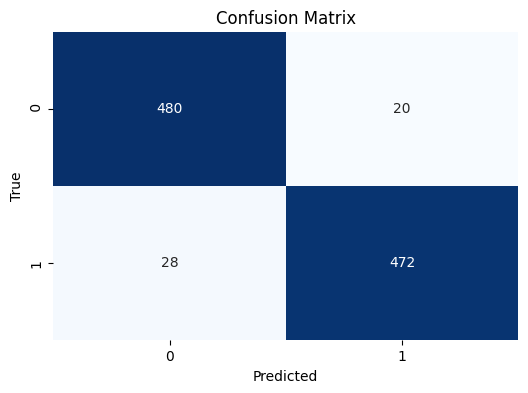

In [ ]:

confusion = confusion_matrix(true_labels, predicted_labels)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

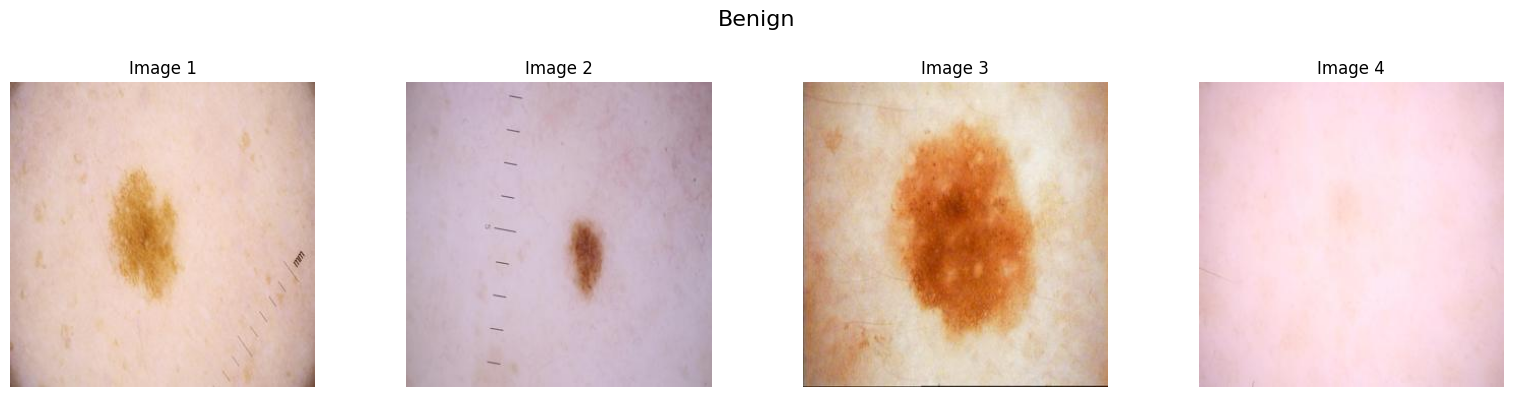

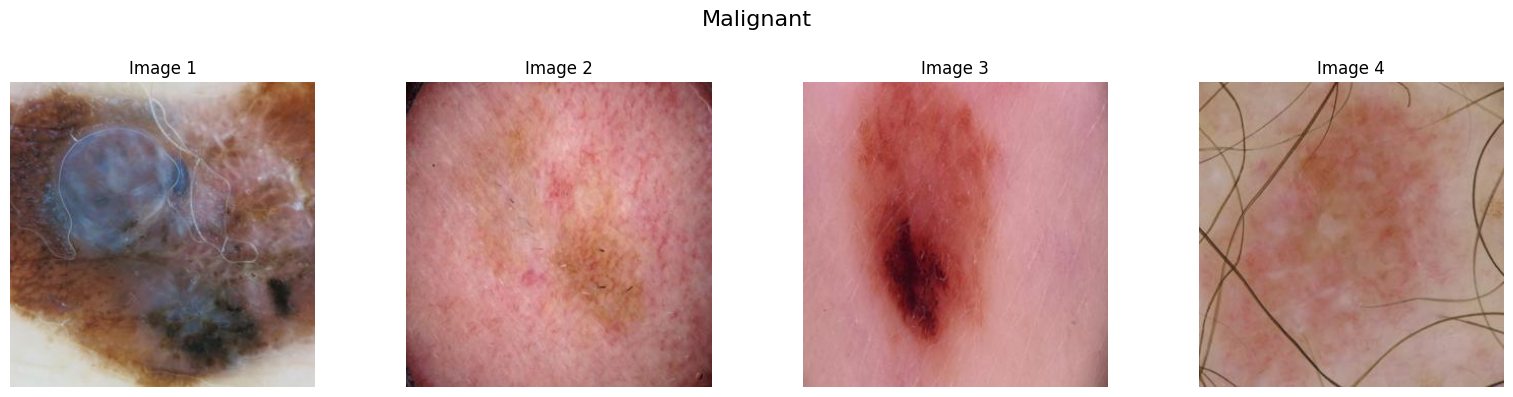

In [ ]:


def visualize_images(image_dir, title, num_images=5):
    # List all image files in the directory
    image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

    # Load and display a subset of images
    num_images = min(num_images, len(image_files))

    fig, axes = plt.subplots(1, num_images, figsize=(16, 4))
    fig.suptitle(title, fontsize=16)
    for i in range(num_images):
        image_path = os.path.join(image_dir, image_files[i])
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB format
        axes[i].imshow(image)
        axes[i].set_title(f"Image {i+1}", fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.8)  # Adjust the spacing between title and images
    plt.show()

# Visualize benign images with title "Benign"
visualize_images(benignPath, title="Benign", num_images=4)

# Visualize malignant images with title "Malignant"
visualize_images(malignantPath, title="Malignant", num_images=4)
